#### **Data Parsing via Docling**

Docling can be used individually as well as via LangChain too. 

In [1]:
# # ============================================================
# # Complex PDF Parsing using Docling
# # PDF -> DoclingDocument -> Markdown / JSON / LangChain Documents
# # ============================================================

# # Install dependencies
# !pip install -q docling langchain-core langchain-text-splitters pandas

import json
from pathlib import Path
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [14]:
# ============================================================
# 1. Input PDF Path
# ============================================================

PDF_PATH = "C:\Data_science\Modern_route\RAG\RAG_data\complex_rag_parsing_sample_with_sunny_image.pdf"
OUTPUT_DIR = Path("C:\Data_science\Modern_route\RAG\RAG_data\docling_output\docling_parsed_output")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PDF path:", PDF_PATH)

PDF path: C:\Data_science\Modern_route\RAG\RAG_data\complex_rag_parsing_sample_with_sunny_image.pdf


In [15]:
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import (
    DocumentConverter,
    PdfFormatOption,
)
from docling.datamodel.base_models import InputFormat

pipeline_options = PdfPipelineOptions()

pipeline_options.generate_page_images = True
pipeline_options.generate_picture_images = True

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_options
        )
    }
)

In [16]:
conversion_result = converter.convert(PDF_PATH)
docling_doc = conversion_result.document

[INFO] 2026-07-08 08:36:56,633 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-08 08:36:56,636 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-07-08 08:36:56,684 [RapidOCR] download_file.py:60: File exists and is valid: C:\Data_science\Modern_route\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-07-08 08:36:56,684 [RapidOCR] main.py:50: Using C:\Data_science\Modern_route\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-07-08 08:36:57,124 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-08 08:36:57,124 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-07-08 08:36:57,140 [RapidOCR] download_file.py:60: File exists and is valid: C:\Data_science\Modern_route\.venv\Lib\site-packages\rapidocr\models\ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-07-08 08:36:57,142 [RapidOCR] main.py:50: Using C:\Data_science\Modern_route\.venv\Lib\site-packages\rapidocr\models\ch_ptocr_mobile_v2

mimetype='image/png' dpi=72 size=Size(width=455.0, height=276.0) uri=AnyUrl('')

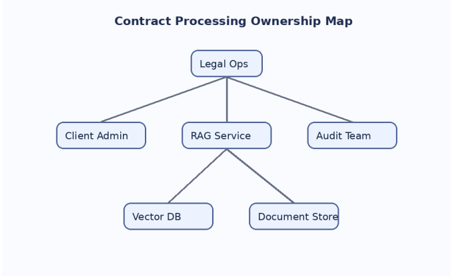

In [17]:
print(docling_doc.pictures[0].image)

In [19]:
print(type(docling_doc.pictures[0].image))

<class 'docling_core.types.doc.document.ImageRef'>


In [20]:
img = docling_doc.pictures[0].image

print(type(img))
print(dir(img))

<class 'docling_core.types.doc.document.ImageRef'>
['__abstractmethods__', '__annotations__', '__class__', '__class_getitem__', '__class_vars__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__fields__', '__fields_set__', '__format__', '__ge__', '__get_pydantic_core_schema__', '__get_pydantic_json_schema__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__pretty__', '__private_attributes__', '__pydantic_complete__', '__pydantic_computed_fields__', '__pydantic_core_schema__', '__pydantic_custom_init__', '__pydantic_decorators__', '__pydantic_extra__', '__pydantic_fields__', '__pydantic_fields_set__', '__pydantic_generic_metadata__', '__pydantic_init_subclass__', '__pydantic_on_complete__', '__pydantic_parent_namespace__', '__pydantic_post_init__', '__pydantic_private__', '__pydantic_root_model__', '__pydantic_serialize

In [21]:
img = docling_doc.pictures[0].image.pil_image

print(type(img))

img.save("figure_1.png")

print("Image saved successfully!")

<class 'PIL.PngImagePlugin.PngImageFile'>
Image saved successfully!


In [18]:
# ============================================================
# 3. Export Parsed Output to Markdown
# ============================================================

markdown_text = docling_doc.export_to_markdown()

markdown_path = OUTPUT_DIR / "parsed_docling_output.md"

with open(markdown_path, "w", encoding="utf-8") as f:
    f.write(markdown_text)

print("Markdown saved at:", markdown_path)


Markdown saved at: C:\Data_science\Modern_route\RAG\RAG_data\docling_output\docling_parsed_output\parsed_docling_output.md


In [3]:
# ============================================================
# 2. Parse PDF using Docling
# ============================================================

from docling.document_converter import DocumentConverter

converter = DocumentConverter()

# Convert PDF into Docling structured document
conversion_result = converter.convert(PDF_PATH)

# Main Docling document object
docling_doc = conversion_result.document

print("Docling conversion completed.")


[INFO] 2026-07-08 08:15:49,920 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-08 08:15:49,943 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-07-08 08:15:50,034 [RapidOCR] download_file.py:60: File exists and is valid: C:\Data_science\Modern_route\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-07-08 08:15:50,034 [RapidOCR] main.py:50: Using C:\Data_science\Modern_route\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-07-08 08:15:51,042 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-08 08:15:51,046 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-07-08 08:15:51,054 [RapidOCR] download_file.py:60: File exists and is valid: C:\Data_science\Modern_route\.venv\Lib\site-packages\rapidocr\models\ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-07-08 08:15:51,055 [RapidOCR] main.py:50: Using C:\Data_science\Modern_route\.venv\Lib\site-packages\rapidocr\models\ch_ptocr_mobile_v2

Docling conversion completed.


In [6]:
print(type(docling_doc))
print(dir(docling_doc))

<class 'docling_core.types.doc.document.DoclingDocument'>
['_DocIndex', '_KVMigrData', '__abstractmethods__', '__annotations__', '__class__', '__class_getitem__', '__class_vars__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__fields__', '__fields_set__', '__format__', '__ge__', '__get_pydantic_core_schema__', '__get_pydantic_json_schema__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__pretty__', '__private_attributes__', '__pydantic_complete__', '__pydantic_computed_fields__', '__pydantic_core_schema__', '__pydantic_custom_init__', '__pydantic_decorators__', '__pydantic_extra__', '__pydantic_fields__', '__pydantic_fields_set__', '__pydantic_generic_metadata__', '__pydantic_init_subclass__', '__pydantic_on_complete__', '__pydantic_parent_namespace__', '__pydantic_post_init__', '__pydantic_private__', '__pydantic_r

In [7]:
print(len(docling_doc.pictures))

10


In [8]:
print(docling_doc.pictures[0])

self_ref='#/pictures/0' parent=RefItem(cref='#/body') children=[RefItem(cref='#/texts/11'), RefItem(cref='#/texts/12'), RefItem(cref='#/texts/13'), RefItem(cref='#/texts/14'), RefItem(cref='#/texts/15'), RefItem(cref='#/texts/16'), RefItem(cref='#/texts/17')] content_layer=<ContentLayer.BODY: 'body'> meta=None label=<DocItemLabel.PICTURE: 'picture'> prov=[ProvenanceItem(page_no=2, bbox=BoundingBox(l=70.8305435180664, t=586.8971862792969, r=525.8306274414062, b=310.7779541015625, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 0))] source=[] comments=[] captions=[] references=[] footnotes=[] image=None annotations=[]


In [9]:
print(converter)

In [10]:
import docling
print(docling.__version__)

AttributeError: module 'docling' has no attribute '__version__'

In [12]:
print(dir(converter))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_convert', '_default_download_filename', '_execute_pipeline', '_get_initialized_pipelines', '_get_pipeline', '_get_pipeline_options_hash', '_process_document', 'allowed_formats', 'convert', 'convert_all', 'convert_string', 'format_to_options', 'initialize_pipeline', 'initialized_pipelines']


In [13]:
from importlib.metadata import version

print(version("docling"))

2.110.0


In [ ]:
# ============================================================
# 3. Export Parsed Output to Markdown
# ============================================================

markdown_text = docling_doc.export_to_markdown()

markdown_path = OUTPUT_DIR / "parsed_docling_output.md"

with open(markdown_path, "w", encoding="utf-8") as f:
    f.write(markdown_text)

print("Markdown saved at:", markdown_path)


Markdown saved at: C:\Data_science\Modern_route\RAG\RAG_data\docling_output\docling_parsed_output\parsed_docling_output.md


In [5]:
# ============================================================
# 4. Export Parsed Output to JSON / Dict
# ============================================================

# Docling versions may expose export_to_dict() or model_dump()
# This fallback handles both styles.

try:
    doc_dict = docling_doc.export_to_dict()
except Exception:
    try:
        doc_dict = docling_doc.model_dump()
    except Exception:
        doc_dict = {"raw_string": str(docling_doc)}

json_path = OUTPUT_DIR / "parsed_docling_output.json"

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(doc_dict, f, indent=2, ensure_ascii=False)

print("JSON saved at:", json_path)

JSON saved at: C:\Data_science\Modern_route\RAG\RAG_data\docling_output\docling_parsed_output\parsed_docling_output.json


In [ ]:
# ============================================================
# 5. Create LangChain Document from Full Markdown
# ============================================================

full_doc = Document(
    page_content=markdown_text,
    metadata={
        "source": PDF_PATH,
        "parser": "docling",
        "content_type": "full_document_markdown"
    }
)

print("LangChain full document created.")
print("Characters:", len(full_doc.page_content))